#Project Groups 1
| ID        | Name                     |
|-----------|---------------------------|
| 445003015 | رتال فواز الحليفي         |
| 445001695 | سايم نفاع السلمي          |
| 44510121  | وسم سلمان الحربي          |
| 445002192 | نجلاء محمد الثنيتي        |
| 445001419 | نجد حسين الجودي           |


In [4]:
from google.colab import files
import pandas as pd
import numpy as np
import json
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [2]:
uploaded = files.upload()

Saving sample.json to sample.json


In [5]:
# Read JSON file and display first rows
df = pd.read_json("sample.json", lines=True)
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A34U973OPOB55U,B00A0CIS5C,"SG ""Sandy""","[0, 0]",I received my phone within a couple of days wi...,5,Bodacious,1371427200,"06 17, 2013"
1,A3T6NQULMXQCJ4,B003Z6YO9Y,Utah non-Mormon stay-at-home mom,"[0, 0]",It made my phone look crappy. The sides kept c...,1,Garbage,1357862400,"01 11, 2013"
2,A2SOTJUM1545TL,B00CHQI57A,"Vik Mehta ""doctorvik""","[1, 2]",I bought this in July. I went to use it for t...,1,started bubbling (like an exploded battery) be...,1376870400,"08 19, 2013"
3,ARIDN94LOCQFD,B005TDWT4I,Steve Taylor,"[0, 0]",This Belkin Case for the iPod Touch 4G is perf...,4,Good Trim Case For The iPod Touch 4G,1327276800,"01 23, 2012"
4,ARTCT91AX3SW1,B003VKQHVW,Jamal,"[1, 1]",this screen protector is amazing... first it w...,5,best screen protector to date,1309305600,"06 29, 2011"


In [6]:
#print number of rows and column names
print("Number of rows:", len(df))
print("Columns:", df.columns.tolist())

Number of rows: 100000
Columns: ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']


In [7]:
# Convert numeric ratings to sentiment labels and show counts
def convert_rating(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["overall"].apply(convert_rating)

print(df["sentiment"].value_counts())

sentiment
positive    76588
negative    12421
neutral     10991
Name: count, dtype: int64


In [8]:
# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Prepare stopwords and lemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Function to clean text
def clean_text(text):

    if not isinstance(text, str):
        return ""

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove URLs (links)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)

    # 3. Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 4. Split text into words (tokens)
    tokens = text.split()

    # 5. Remove stopwords (common words with no meaning)
    tokens = [w for w in tokens if w not in stop_words]

    # 6. Lemmatize words (convert to base form)
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # 7. Join words back into a cleaned sentence
    return " ".join(tokens)

df["clean_text"] = df["reviewText"].apply(clean_text)

print("Sample cleaned text:")
print(df["clean_text"].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Sample cleaned text:
0    received phone within couple day problem big b...
1    made phone look crappy side kept coming thing ...
2    bought july went use first time august started...
3    belkin case ipod touch 4g perfect cover help h...
4    screen protector amazing first easy install to...
Name: clean_text, dtype: object


In [9]:
# Separate features (clean text) and labels (sentiment)
X = df["clean_text"]
y = df["sentiment"]

# First split: 70% training, 30% temporary set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: split the temporary set into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Print final dataset sizes
print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))

Train size: 70000
Val size: 15000
Test size: 15000


In [10]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

# Fit on training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)
# Transform validation data using the same vocabulary
X_val_tfidf   = tfidf.transform(X_val)
# Transform test data using the same vocabulary
X_test_tfidf  = tfidf.transform(X_test)

# Show the shape of TF-IDF matrices
print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (val):", X_val_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

# Indicate that the processed data is ready for the next steps
print("\nREADY for next students:")
print("→ X_train_tfidf")
print("→ X_val_tfidf")
print("→ X_test_tfidf")
print("→ y_train, y_val, y_test")

TF-IDF shape (train): (70000, 50000)
TF-IDF shape (val): (15000, 50000)
TF-IDF shape (test): (15000, 50000)

READY for next students:
→ X_train_tfidf
→ X_val_tfidf
→ X_test_tfidf
→ y_train, y_val, y_test


##Random forest

In [11]:
# Define hyperparameter search space for Random Forest
param = {
    'n_estimators': [50, 100],  # Number of trees
    'max_depth': [5, 10, 20],       # Maximum depth of trees
    'max_features': ['sqrt'],    # Features to consider for best split
    'min_samples_split': [5, 10],       # Minimum samples required to split a node

}

# Create base Random Forest model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Oversampling setup and number of search iterations
N_ITERATIONS = 10
ros = RandomOverSampler(random_state=42)

#  Random Oversampling applied
X_train_over, y_train_over = ros.fit_resample(X_train_tfidf, y_train)

# Show dataset size before and after oversampling
print("Original training size:", X_train_tfidf.shape)
print("Oversampled training size:", X_train_over.shape)

Original training size: (70000, 50000)
Oversampled training size: (160833, 50000)


In [12]:
# Set up RandomizedSearchCV to search for the best Random Forest parameters
print("Initializing RandomizedSearchCV...")
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param,
    n_iter=N_ITERATIONS,
    scoring='accuracy',
    cv=3,                         #  3-fold cross-validation
    random_state=42,
    verbose=2,
    n_jobs=-1
)

Initializing RandomizedSearchCV...


In [13]:
# Start the Random Forest tuning process
print(f"Starting Randomized Forest Tuning (Testing {N_ITERATIONS*3} )...")

# Fit RandomizedSearchCV on the oversampled training data
rf_random_search.fit(X_train_over, y_train_over)

print("Randomized Search tuning complete.")

# Get the best model found during the search
best_rf_model = rf_random_search.best_estimator_

# Display the best parameters and best cross-validation score
print(f"Best Parameters: {rf_random_search.best_params_}")
print(f"Best Training Score (CV): {rf_random_search.best_score_:.4f}")

Starting Randomized Forest Tuning (Testing 30 )...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Randomized Search tuning complete.
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 20}
Best Training Score (CV): 0.7815


In [14]:
# Get class probability predictions for the validation set
rf_val_probs = best_rf_model.predict_proba(X_val_tfidf)
print(f"Validation Probability Matrix Shape: {rf_val_probs.shape}")

# Get class probability predictions for the test set
rf_test_probs = best_rf_model.predict_proba(X_test_tfidf)
print(f"Test Probability Matrix Shape: {rf_test_probs.shape}")

# Predict final labels for the validation set
rf_val_preds = best_rf_model.predict(X_val_tfidf)

# Calculate validation accuracy
val_acc = accuracy_score(y_val, rf_val_preds)
print(f"Tuned RF Validation Accuracy: {val_acc:.4f}")

Validation Probability Matrix Shape: (15000, 3)
Test Probability Matrix Shape: (15000, 3)
Tuned RF Validation Accuracy: 0.7179



--- Random Forest Validation Classification Report ---
              precision    recall  f1-score   support

    negative       0.44      0.68      0.54      1863
     neutral       0.27      0.41      0.33      1648
    positive       0.92      0.77      0.83     11489

    accuracy                           0.72     15000
   macro avg       0.54      0.62      0.57     15000
weighted avg       0.79      0.72      0.74     15000



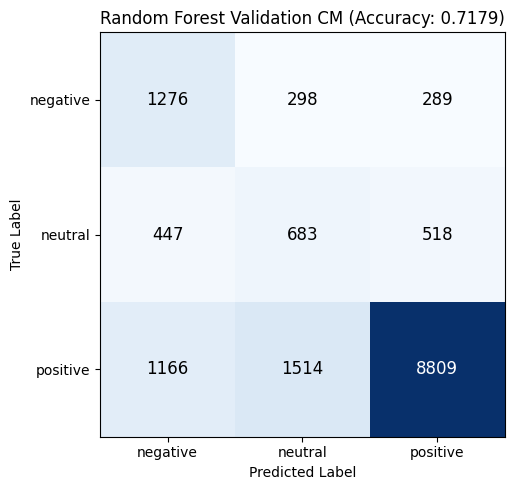

In [15]:
print("\n--- Random Forest Validation Classification Report ---")
print(classification_report(y_val, rf_val_preds))

# Define class order for confusion matrix
classes = ["negative", "neutral", "positive"]

# Compute confusion matrix
cm = confusion_matrix(y_val, rf_val_preds, labels=classes)

# Create plot figure
plt.figure(figsize=(6, 5))

# Display confusion matrix as an image
plt.imshow(cm, cmap="Blues")

# Set x and y axis labels
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)


# Add numbers inside each cell
for i in range(len(classes)):
    for j in range(len(classes)):
        cell_val = cm[i, j]
        thresh = cm.max() / 2.
        text_color = "white" if cell_val > thresh else "black"

        plt.text(j, i, cell_val, ha="center", va="center", color=text_color, fontsize=12)

# Add title and axis labels
plt.title(f'Random Forest Validation CM (Accuracy: {val_acc:.4f})')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

##MultinomialNB

In [16]:
# Create the Multinomial Naive Bayes model (alpha=1.0 for Laplace smoothing)
nb_model = MultinomialNB(alpha=1.0)

# Train the model on the training data
nb_model.fit(X_train_over, y_train_over)

MultinomialNB()

In [17]:
# Predict the sentiment labels for the validation set
y_val_pred = nb_model.predict(X_val_tfidf)

# Calculate accuracy on the validation set
val_acc = accuracy_score(y_val, y_val_pred)
print(f"MultinomialNB Validation Accuracy: {val_acc:.4f}")

MultinomialNB Validation Accuracy: 0.7295



--- MultinomialNB Validation Classification Report ---
              precision    recall  f1-score   support

    negative       0.50      0.67      0.57      1863
     neutral       0.27      0.51      0.35      1648
    positive       0.94      0.77      0.85     11489

    accuracy                           0.73     15000
   macro avg       0.57      0.65      0.59     15000
weighted avg       0.81      0.73      0.76     15000



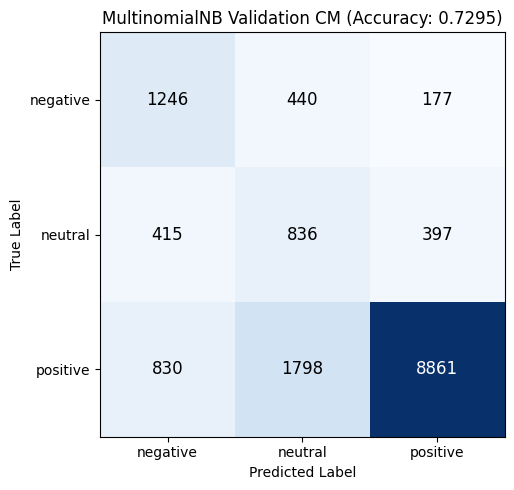

In [18]:
print("\n--- MultinomialNB Validation Classification Report ---")
print(classification_report(y_val, y_val_pred))

# Define class order for confusion matrix
classes = ["negative", "neutral", "positive"]

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred, labels=classes)

# Create plot figure
plt.figure(figsize=(6, 5))

# Display confusion matrix as an image
plt.imshow(cm, cmap="Blues")

# Set x and y axis labels
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)


# Add numbers inside each cell
for i in range(len(classes)):
    for j in range(len(classes)):
        cell_val = cm[i, j]
        thresh = cm.max() / 2.
        text_color = "white" if cell_val > thresh else "black"

        plt.text(j, i, cell_val, ha="center", va="center", color=text_color, fontsize=12)

# Add title and axis labels
plt.title(f'MultinomialNB Validation CM (Accuracy: {val_acc:.4f})')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

#Support Vector Machine



In [19]:
# Define the hyperparameter search space
param_svm = {
    # C: Regularization parameter. Smaller C = stronger regularization.
    'C': [0.01, 0.1, 1.0, 10.0],
    # class_weight: Handles class imbalance (e.g., more 'positive' samples).
    'class_weight': [None, 'balanced'],
}

N_ITERATIONS = 8 # Total parameter settings to sample

In [20]:
# Initialize the LinearSVC model
# dual=False: Faster for large, sparse datasets (TF-IDF)
# max_iter=2000: Ensure the model converges
svm_base = LinearSVC(random_state=42, dual=False, max_iter=2000)

print("Initializing RandomizedSearchCV for LinearSVC...")

# Setup RandomizedSearchCV
svm_random_search = RandomizedSearchCV(
    estimator=svm_base,
    param_distributions=param_svm,
    n_iter=N_ITERATIONS,
    scoring='accuracy',
    cv=3,                      # 3-fold Cross-Validation
    random_state=42,
    verbose=2,
    n_jobs=-1                  # Use all CPU cores
)

print(f"Starting LinearSVC Tuning (Testing {N_ITERATIONS*3} models on CPU)...")

# Fit the search on the TRAINING data
svm_random_search.fit(X_train_tfidf, y_train)

print("Randomized Search tuning complete.")

Initializing RandomizedSearchCV for LinearSVC...
Starting LinearSVC Tuning (Testing 24 models on CPU)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Randomized Search tuning complete.


In [21]:
# Extract the best model found by the search
best_svm_model = svm_random_search.best_estimator_

# Display best parameters and training CV score
print(f"\nBest Parameters: {svm_random_search.best_params_}")
print(f"Best Training Score (CV): {svm_random_search.best_score_:.4f}")

# Evaluate on Validation Set

# Predict labels using the best model
svm_val_preds = best_svm_model.predict(X_val_tfidf)
val_acc = accuracy_score(y_val, svm_val_preds)
print(f"\nTuned SVM (LinearSVC) Validation Accuracy: {val_acc:.4f}")



Best Parameters: {'class_weight': 'balanced', 'C': 0.1}
Best Training Score (CV): 0.8224

Tuned SVM (LinearSVC) Validation Accuracy: 0.8237



--- LinearSVC Validation Classification Report ---
              precision    recall  f1-score   support

    negative       0.63      0.65      0.64      1863
     neutral       0.41      0.30      0.35      1648
    positive       0.90      0.93      0.91     11489

    accuracy                           0.82     15000
   macro avg       0.65      0.63      0.63     15000
weighted avg       0.81      0.82      0.82     15000



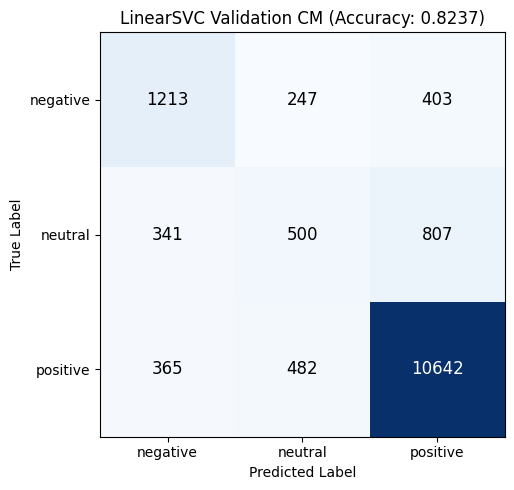

In [22]:
# Print classification report for LinearSVC on validation set
print("\n--- LinearSVC Validation Classification Report ---")
print(classification_report(y_val, svm_val_preds))

# Define class order for confusion matrix
classes = ["negative", "neutral", "positive"]

# Compute confusion matrix
cm = confusion_matrix(y_val, svm_val_preds, labels=classes)

# Create plot figure
plt.figure(figsize=(6, 5))

# Display confusion matrix as an image
plt.imshow(cm, cmap="Blues")

# Set x and y axis labels
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)


# Add numbers inside each cell
for i in range(len(classes)):
    for j in range(len(classes)):
        cell_val = cm[i, j]
        thresh = cm.max() / 2.
        text_color = "white" if cell_val > thresh else "black"
        plt.text(j, i, cell_val, ha="center", va="center", color=text_color, fontsize=12)

# Add title and axis labels
plt.title(f'LinearSVC Validation CM (Accuracy: {val_acc:.4f})')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Adjust layout and show plot
plt.tight_layout()
plt.show()


#Stacking Ensemble


Stacking Validation Accuracy: 0.8257

FINAL Stacking Test Accuracy: 0.8263

--- Stacking Ensemble TEST Classification Report ---
              precision    recall  f1-score   support

    negative       0.68      0.58      0.63      1863
     neutral       0.43      0.26      0.33      1649
    positive       0.88      0.95      0.91     11488

    accuracy                           0.83     15000
   macro avg       0.66      0.60      0.62     15000
weighted avg       0.80      0.83      0.81     15000



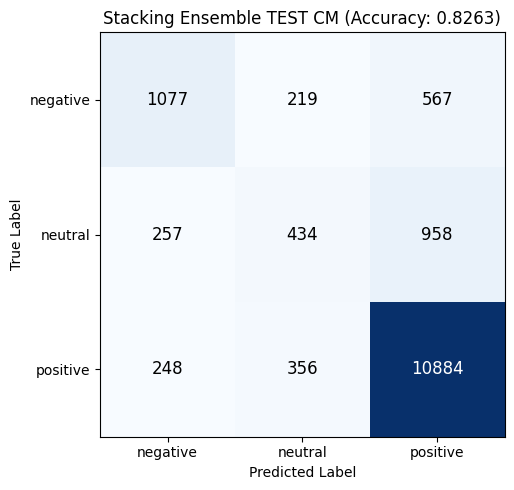

In [23]:
# 1. Prepare base models

# Use tuned Random Forest
rf_model_stack = best_rf_model

# Use tuned Multinomial Naive Bayes (already trained)
nb_model_stack = nb_model

# Use tuned LinearSVC as base for calibration
svm_model_stacking = best_svm_model

# Calibrate SVM to get probability outputs
svm_calibrated = CalibratedClassifierCV(svm_model_stacking, method='sigmoid', cv=3)
svm_calibrated.fit(X_train_tfidf, y_train)

# 2. Create stacking features
def get_stacked_features(X):
    rf_probs = rf_model_stack.predict_proba(X)
    nb_probs = nb_model_stack.predict_proba(X)
    svm_probs = svm_calibrated.predict_proba(X)
    return np.column_stack([rf_probs, nb_probs, svm_probs])

X_train_stacked = get_stacked_features(X_train_tfidf)
X_val_stacked   = get_stacked_features(X_val_tfidf)
X_test_stacked  = get_stacked_features(X_test_tfidf)

# 3. Train meta-model (Logistic Regression on stacked features)
meta_model = LogisticRegression(C=0.1, random_state=42, max_iter=1000)
meta_model.fit(X_train_stacked, y_train)

# 4. Evaluate on validation set (for tuning/analysis)
stacking_val_preds = meta_model.predict(X_val_stacked)
stacking_val_acc   = accuracy_score(y_val, stacking_val_preds)
print(f"\nStacking Validation Accuracy: {stacking_val_acc:.4f}")

# 5. FINAL evaluation on TEST set
stacking_test_preds = meta_model.predict(X_test_stacked)
stacking_test_acc   = accuracy_score(y_test, stacking_test_preds)
print(f"\nFINAL Stacking Test Accuracy: {stacking_test_acc:.4f}")

print("\n--- Stacking Ensemble TEST Classification Report ---")
print(classification_report(y_test, stacking_test_preds))

# 6. Confusion Matrix on TEST set
classes = ["negative", "neutral", "positive"]

# Compute confusion matrix with fixed class order
cm = confusion_matrix(y_test, stacking_test_preds, labels=classes)

# Create plot figure
plt.figure(figsize=(6, 5))

# Display confusion matrix as an image
plt.imshow(cm, cmap="Blues")

# Set x and y axis labels
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Add numbers inside each cell
for i in range(len(classes)):
    for j in range(len(classes)):
        cell_val = cm[i, j]
        thresh = cm.max() / 2.0
        text_color = "white" if cell_val > thresh else "black"
        plt.text(j, i, cell_val, ha="center", va="center",
                 color=text_color, fontsize=12)

# Add title and axis labels
plt.title(f'Stacking Ensemble TEST CM (Accuracy: {stacking_test_acc:.4f})')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Adjust layout and show plot
plt.tight_layout()
plt.show()


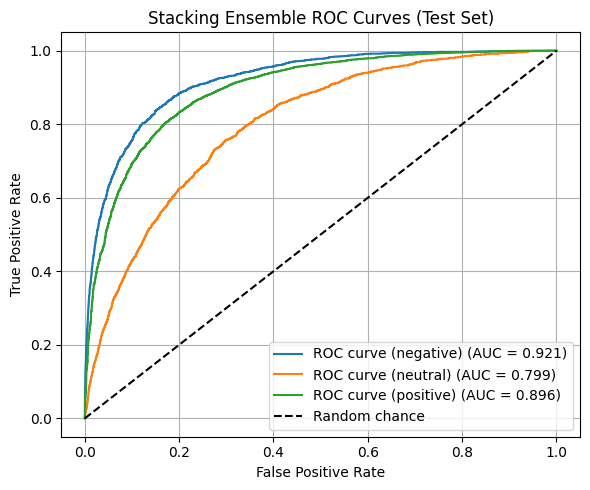

In [24]:
# 1) Define class order
classes = ["negative", "neutral", "positive"]

# 2) Get predicted probabilities from the stacking model
stacking_proba = meta_model.predict_proba(X_test_stacked)

# 3) Binarize the true labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=classes)   # shape: (n_samples, 3)

# 4) Compute FPR, TPR, AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], stacking_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5) Plot ROC curves for each class
plt.figure(figsize=(6, 5))

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"ROC curve ({classes[i]}) (AUC = {roc_auc[i]:.3f})"
    )

# 6) Add random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random chance')

# 7) Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stacking Ensemble ROC Curves (Test Set)")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()
